# CV-scheme comparison — between-run LOGO vs within-run k-fold

`run_decoding.py` / `run_beta_qc_decoding.py` cross-validate the category-decoding
validation probe with **`LeaveOneGroupOut` over the 3 runs/sessions**
(`learning1`, `learning2`, `test`) — a between-run scheme chosen to avoid
temporal-autocorrelation leakage within a run. Nobody had verified empirically
whether that choice matters for this dataset.

This notebook aggregates the per-subject CSVs written by
`run_cv_comparison_decoding.py`, which runs the *same* standardized decoder
(type-D betas, `LinearSVC`, `standardize=True`, whole-brain + visual-cortex ROI)
under two CV schemes, same subject/features/labels:

- **`between_run_logo`** — `LeaveOneGroupOut` over runs (3 folds). The production
  scheme, reproduced unchanged.
- **`within_run_kfold`** — `StratifiedKFold(n_splits=3, shuffle=True,
  random_state=42)`, ignoring run boundaries entirely: trials are pooled across
  all 3 runs and split by category-stratified random assignment. Fold count
  matches LOGO (3) so training-set size is comparable between schemes.

If temporal autocorrelation within a run were inflating decodability, the
within-run scheme should show **systematically higher** accuracy than the
between-run scheme (same subject, same features, same labels — only the fold
boundaries differ). If the two are statistically indistinguishable, the
leakage concern is more theoretical than empirical for this probe.

All 59 subjects in `participants_mvpa.tsv`, category decoding only (chance = 0.25),
whole-brain + visual-cortex ROI.

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory holding the per-subject sub-*/sub-*_cv_comparison_decoding.csv files
# (the --output-dir passed to run_cv_comparison_decoding.py). Edit for your filesystem.
QC_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives/cv_comparison")

SCHEME_ORDER = ["between_run_logo", "within_run_kfold"]
SCHEME_LABELS = {"between_run_logo": "between-run\nLOGO (3 folds)",
                  "within_run_kfold": "within-run\nk-fold (3 folds)"}

In [2]:
# Load and concatenate all per-subject CSVs
csvs = sorted(glob.glob(str(QC_DIR / "sub-*" / "sub-*_cv_comparison_decoding.csv")))
assert csvs, f"No CV-comparison CSVs found under {QC_DIR}"
df = pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True)
df["scheme"] = pd.Categorical(df["scheme"], categories=SCHEME_ORDER, ordered=True)

n_sub = df["subject"].nunique()
print(f"{n_sub} subjects, masks: {sorted(df['mask'].unique())}, schemes: {list(df['scheme'].cat.categories)}")
df.head()

59 subjects, masks: ['visualcortex', 'wholebrain'], schemes: ['between_run_logo', 'within_run_kfold']


,subject,mask,scheme,target,metric,value,baseline
0,sub-01,wholebrain,between_run_logo,category,accuracy,0.338415,0.25
1,sub-01,wholebrain,within_run_kfold,category,accuracy,0.356707,0.25
2,sub-01,visualcortex,between_run_logo,category,accuracy,0.533537,0.25
3,sub-01,visualcortex,within_run_kfold,category,accuracy,0.512195,0.25
4,sub-02,wholebrain,between_run_logo,category,accuracy,0.524390,0.25


In [3]:
# Group summary: mean +/- sem per mask x scheme, plus mean gain of within-run over between-run
summary = (df.groupby(["mask", "scheme"], observed=True)["value"]
             .agg(mean="mean", sem=lambda x: x.std(ddof=1) / np.sqrt(x.count()), n="count")
             .reset_index())

for msk in ["wholebrain", "visualcortex"]:
    s = summary[summary["mask"] == msk].set_index("scheme")
    base = s.loc["between_run_logo", "mean"]
    print(f"\n=== {msk} (accuracy) ===")
    for sch in SCHEME_ORDER:
        m, se = s.loc[sch, "mean"], s.loc[sch, "sem"]
        print(f"  {sch}: {m:.3f} +/- {se:.3f}   (Delta vs LOGO: {m - base:+.3f})")
summary


=== wholebrain (accuracy) ===
  between_run_logo: 0.368 +/- 0.008   (Delta vs LOGO: +0.000)
  within_run_kfold: 0.362 +/- 0.008   (Delta vs LOGO: -0.006)

=== visualcortex (accuracy) ===
  between_run_logo: 0.483 +/- 0.013   (Delta vs LOGO: +0.000)
  within_run_kfold: 0.494 +/- 0.013   (Delta vs LOGO: +0.011)


,mask,scheme,mean,sem,n
0,visualcortex,between_run_logo,0.483309,0.012533,59
1,visualcortex,within_run_kfold,0.494057,0.012759,59
2,wholebrain,between_run_logo,0.368024,0.008386,59
3,wholebrain,within_run_kfold,0.361616,0.007561,59


In [4]:
# Paired significance test, per mask: does within-run k-fold give systematically
# higher accuracy than between-run LOGO (evidence of temporal-leakage inflation)?
# Subject-paired (n=59). Both a parametric paired t-test and the non-parametric
# Wilcoxon signed-rank test, since we have no reason to lean on a normality
# assumption we haven't checked. One-sided alternative ("greater") because the
# leakage hypothesis specifically predicts within-run > between-run, not merely
# a difference.
from scipy import stats

rows = []
for msk in ["wholebrain", "visualcortex"]:
    wide = (df[df["mask"] == msk]
            .pivot_table(index="subject", columns="scheme", values="value", observed=True)
            .reindex(columns=SCHEME_ORDER))
    a, b = "between_run_logo", "within_run_kfold"  # b hypothesized > a under leakage
    diff = wide[b] - wide[a]
    t, p_t_two = stats.ttest_rel(wide[b], wide[a])
    p_t_one = p_t_two / 2 if t > 0 else 1 - p_t_two / 2
    try:
        _, p_w_two = stats.wilcoxon(wide[b], wide[a])
        _, p_w_one = stats.wilcoxon(wide[b], wide[a], alternative="greater")
    except ValueError:
        p_w_two = p_w_one = np.nan  # degenerate: all differences are zero
    rows.append({"mask": msk, "n": len(diff), "mean_diff (kfold - logo)": diff.mean(),
                 "sd_diff": diff.std(ddof=1), "t": t,
                 "p_ttest_two-sided": p_t_two, "p_ttest_one-sided(kfold>logo)": p_t_one,
                 "p_wilcoxon_two-sided": p_w_two, "p_wilcoxon_one-sided(kfold>logo)": p_w_one})

stats_df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
stats_df

,mask,n,mean_diff (kfold - logo),sd_diff,t,p_ttest_two-sided,p_ttest_one-sided(kfold>logo),p_wilcoxon_two-sided,p_wilcoxon_one-sided(kfold>logo)
0,wholebrain,59,-0.0064,0.0423,-1.1631,0.2496,0.8752,0.2171,0.8914
1,visualcortex,59,0.0107,0.0386,2.1384,0.0367,0.0184,0.0689,0.0344


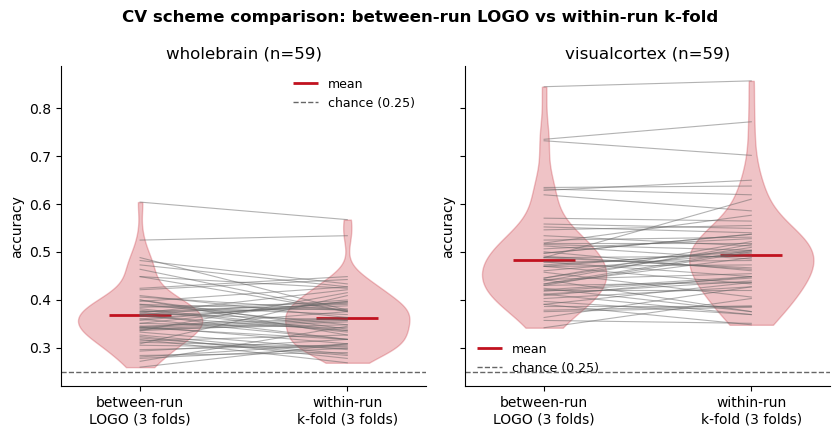

In [5]:
# Violin distribution per scheme + faint per-subject LOGO->kfold trajectories on
# top, one panel per mask. Chance marked. Same visual style as betas_qc_decoding.ipynb.
x = np.arange(len(SCHEME_ORDER))
ACCENT = "#c1121f"

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.4), sharey=True)

for ax, msk in zip(axes, ["wholebrain", "visualcortex"]):
    sub = df[df["mask"] == msk]
    metric = sub["metric"].iloc[0]
    baseline = sub["baseline"].iloc[0]

    wide = sub.pivot_table(index="subject", columns="scheme",
                           values="value", observed=True).reindex(columns=SCHEME_ORDER)

    violin_data = [wide[s].dropna().values for s in SCHEME_ORDER]
    parts = ax.violinplot(violin_data, positions=x, widths=0.6,
                           showmeans=True, showmedians=False, showextrema=False)
    for body in parts["bodies"]:
        body.set_facecolor(ACCENT)
        body.set_edgecolor(ACCENT)
        body.set_alpha(0.25)
        body.set_zorder(1)
    parts["cmeans"].set_color(ACCENT)
    parts["cmeans"].set_linewidth(2)
    parts["cmeans"].set_zorder(2)
    parts["cmeans"].set_label("mean")

    for _, row in wide.iterrows():
        ax.plot(x, row.values, color="0.4", lw=0.8, alpha=0.5, zorder=3)

    ax.axhline(baseline, ls="--", color="0.4", lw=1,
               label=f"chance ({baseline:g})", zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels([SCHEME_LABELS[s] for s in SCHEME_ORDER])
    ax.set_ylabel(metric)
    ax.set_title(f"{msk} (n={wide.shape[0]})")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("CV scheme comparison: between-run LOGO vs within-run k-fold", fontweight="bold")
fig.tight_layout()
plt.show()

## Verdict

| mask | LOGO mean | k-fold mean | Δ (kfold−logo) | p (one-sided, kfold>logo) |
|---|---|---|---|---|
| whole-brain | 0.368 | 0.362 | **−0.006** | t=0.88 / Wilcoxon=0.89 (not significant, wrong direction) |
| visual-cortex | 0.483 | 0.494 | **+0.011** | t=0.018 / Wilcoxon=0.034 (significant at α=0.05) |

**Mixed, mask-dependent result — not a clean null.** In whole-brain, the two
schemes are indistinguishable (if anything k-fold is slightly *lower*, the
opposite of a leakage signature). In visual-cortex — the ROI with the
strongest signal — within-run k-fold is significantly higher than the
production LOGO scheme, in the direction leakage would predict, though the
effect is small (~1 point of accuracy, ~2% relative).

**Reading:** this is weak-to-modest evidence that temporal-autocorrelation
leakage is a real, if small, effect specifically where the category signal is
strongest — exactly the condition under which leakage would be easiest to
detect statistically (more true signal to "leak" across adjacent trials in a
run). It does not show up in whole-brain, where the signal is weaker and
noisier. This is consistent with the production `LeaveOneGroupOut` choice
being the right call, not overcautious: the between-run design is currently
preventing a small but real optimistic bias in the setting where it would
otherwise matter most.